# Machine Learning - Lab 3 - Wine Linear Regression

## 1. Setup

### (1a) Imports and config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 100})

RANDOM_STATE = 1

### (1b) Data Loading + Target Choice

In [2]:
# Wczytanie zbioru WINE
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Zmienna docelowa: 'alcohol' (ciągła, dobra wariancja)
# Pozostałe cechy chemiczne służą jako predyktory
TARGET = 'alcohol'
y = df[TARGET].values
feature_cols = [col for col in df.columns if col != TARGET]
X = df[feature_cols].values

print(f"Cechy wejściowe ({len(feature_cols)}):", feature_cols)
print(f"\nZmienna docelowa '{TARGET}': min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")
print(f"Kształt X: {X.shape}")

df.head()

Cechy wejściowe (12): ['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Zmienna docelowa 'alcohol': min=11.03, max=14.83, mean=13.00
Kształt X: (178, 12)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 2. EDA

### (2a) Target Distribution + Correlations

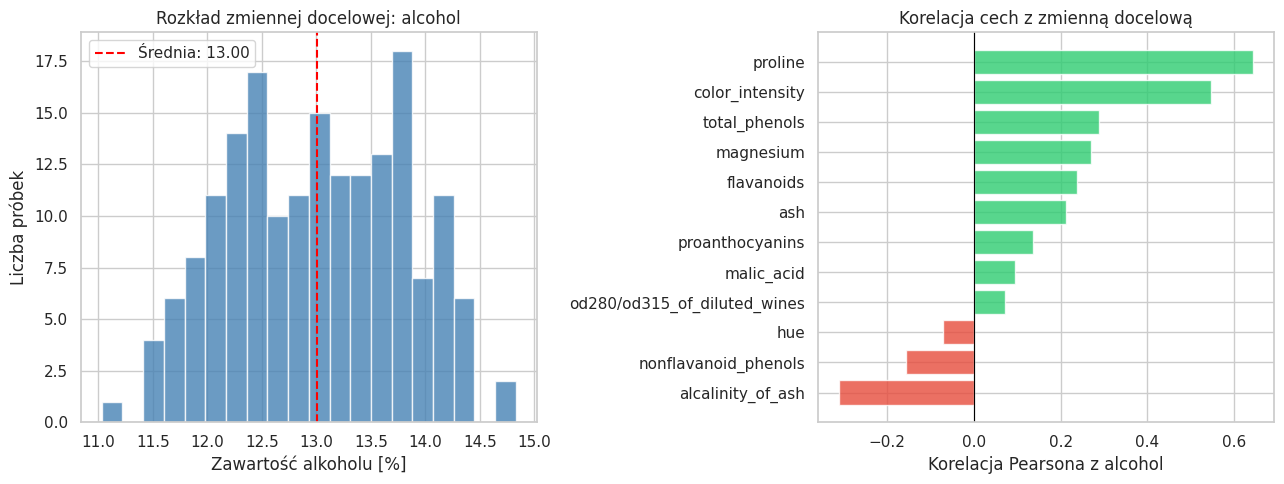

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram zmiennej docelowej
axes[0].hist(y, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Średnia: {y.mean():.2f}')
axes[0].set_xlabel('Zawartość alkoholu [%]')
axes[0].set_ylabel('Liczba próbek')
axes[0].set_title('Rozkład zmiennej docelowej: alcohol')
axes[0].legend()

# Korelacja Pearsona każdej cechy z 'alcohol'
correlations = df[feature_cols].corrwith(df[TARGET]).sort_values()
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in correlations]
axes[1].barh(correlations.index, correlations.values, color=colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Korelacja Pearsona z alcohol')
axes[1].set_title('Korelacja cech z zmienną docelową')

plt.tight_layout()
plt.show()

### (2b) Stats + Missing Values

In [4]:
print("=== Podstawowe statystyki ===")
display(df.describe().round(3))

print("\n=== Braki danych ===")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ Brak wartości NaN — zbiór WINE jest kompletny.")
else:
    print(missing[missing > 0])

=== Podstawowe statystyki ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000



=== Braki danych ===
✓ Brak wartości NaN — zbiór WINE jest kompletny.


### (2c) Feature distributions

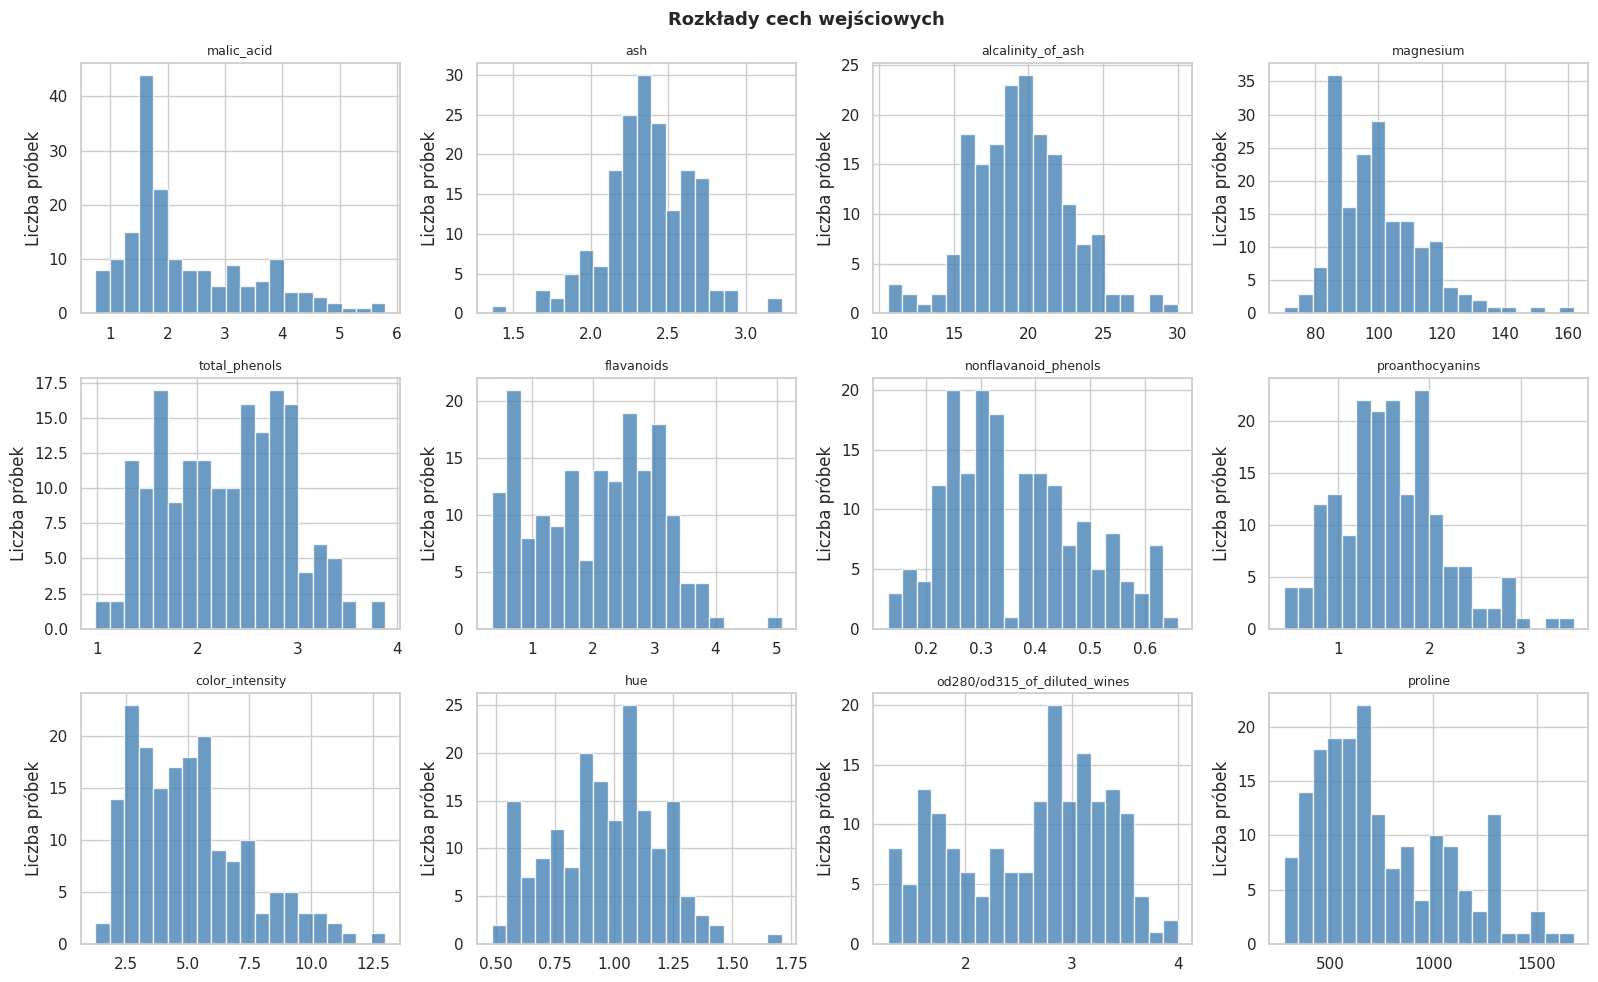

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Liczba próbek')

# Ukrycie pustego subplotu (13 cech → 12 subplotów w 3x4, jedna cecha to TARGET)
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Rozkłady cech wejściowych', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### (2d) Outliers Detection (IQR)

In [6]:
# Metoda IQR: wartości poza [Q1 - 1.5*IQR, Q3 + 1.5*IQR] uznajemy za outliery
outlier_summary = []

for col in df.columns:  # sprawdzamy też TARGET
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'cecha': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'dolna granica': lower,
        'górna granica': upper,
        'n outlierów': n_out,
        '% outlierów': round(100 * n_out / len(df), 1)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('n outlierów', ascending=False)
display(outlier_df[['cecha', 'n outlierów', '% outlierów', 'dolna granica', 'górna granica']].reset_index(drop=True))

print(f"\nŁączna liczba outlierów (wierszy z ≥1 outliersem w dowolnej cesze):")
mask = pd.Series(False, index=df.index)
for col in df.columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask |= (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
print(f"  {mask.sum()} wierszy ({100*mask.mean():.1f}% zbioru)")

,cecha,n outlierów,% outlierów,dolna granica,górna granica
0,magnesium,4,2.2,59.50000,135.50000
1,alcalinity_of_ash,4,2.2,10.75000,27.95000
2,color_intensity,4,2.2,-1.25000,10.67000
3,malic_acid,3,1.7,-0.61750,5.30250
4,ash,3,1.7,1.68875,3.07875
5,proanthocyanins,2,1.1,0.20000,3.00000
6,hue,1,0.6,0.27625,1.62625
7,alcohol,0,0.0,10.39000,15.65000
8,total_phenols,0,0.0,0.15625,4.38625
9,nonflavanoid_phenols,0,0.0,0.01875,0.68875



Łączna liczba outlierów (wierszy z ≥1 outliersem w dowolnej cesze):
  17 wierszy (9.6% zbioru)


#### (2e) Boxplots (Outliers Visualization)

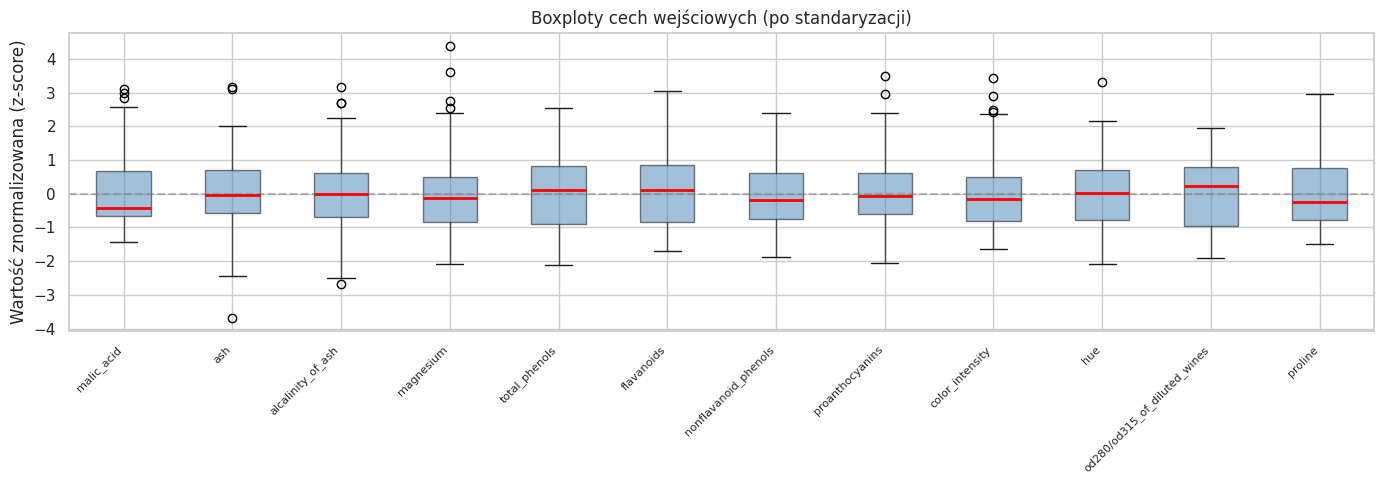

In [7]:
# Boxplot wymaga standaryzacji skali dla porównywalności —
# cechy mają bardzo różne zakresy (np. proline: 0-1680 vs nonflavanoid_phenols: 0.1-0.7)
from sklearn.preprocessing import StandardScaler

df_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df[feature_cols]),
    columns=feature_cols
)

plt.figure(figsize=(14, 5))
df_scaled.boxplot(ax=plt.gca(), vert=True, patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.5),
                  medianprops=dict(color='red', linewidth=2))
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Boxploty cech wejściowych (po standaryzacji)')
plt.ylabel('Wartość znormalizowana (z-score)')
plt.tight_layout()
plt.show()

### (2f) Scatter Plots (top4 strongest correlations with target)

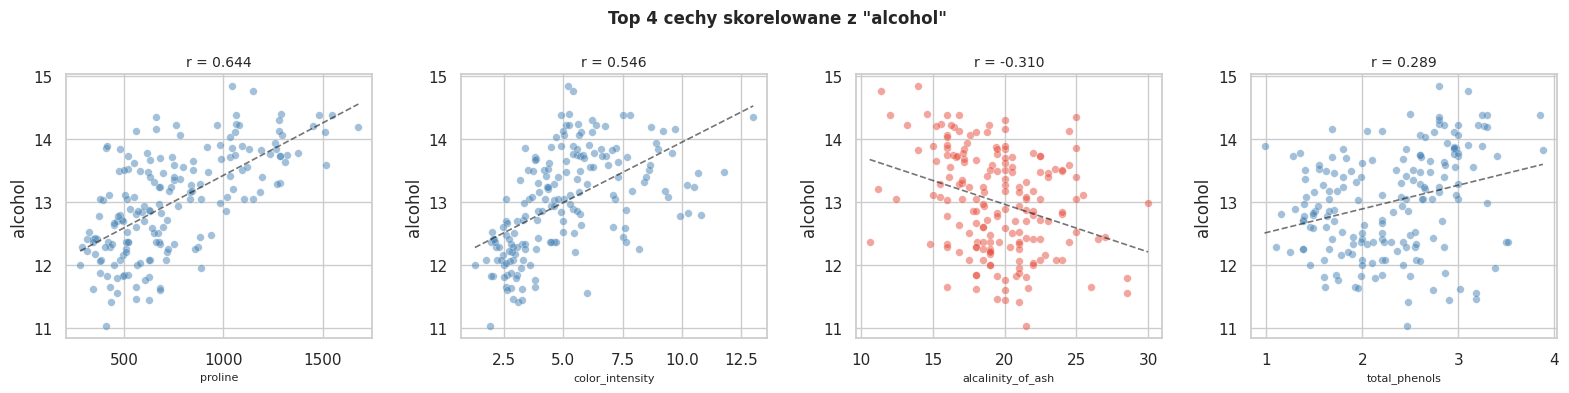

In [8]:
# Bierzemy top 4 cechy wg bezwzględnej korelacji z 'alcohol'
top_features = correlations.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feat in zip(axes, top_features):
    corr_val = correlations[feat]
    ax.scatter(df[feat], df[TARGET], alpha=0.5, s=30,
               color='steelblue' if corr_val > 0 else '#e74c3c',
               edgecolors='white', linewidth=0.3)
    
    # Linia trendu
    m, b = np.polyfit(df[feat], df[TARGET], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', alpha=0.6, linewidth=1.2)
    
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(TARGET)
    ax.set_title(f'r = {corr_val:.3f}', fontsize=10)

plt.suptitle(f'Top 4 cechy skorelowane z "{TARGET}"', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### (2g) Correlation Heatmap

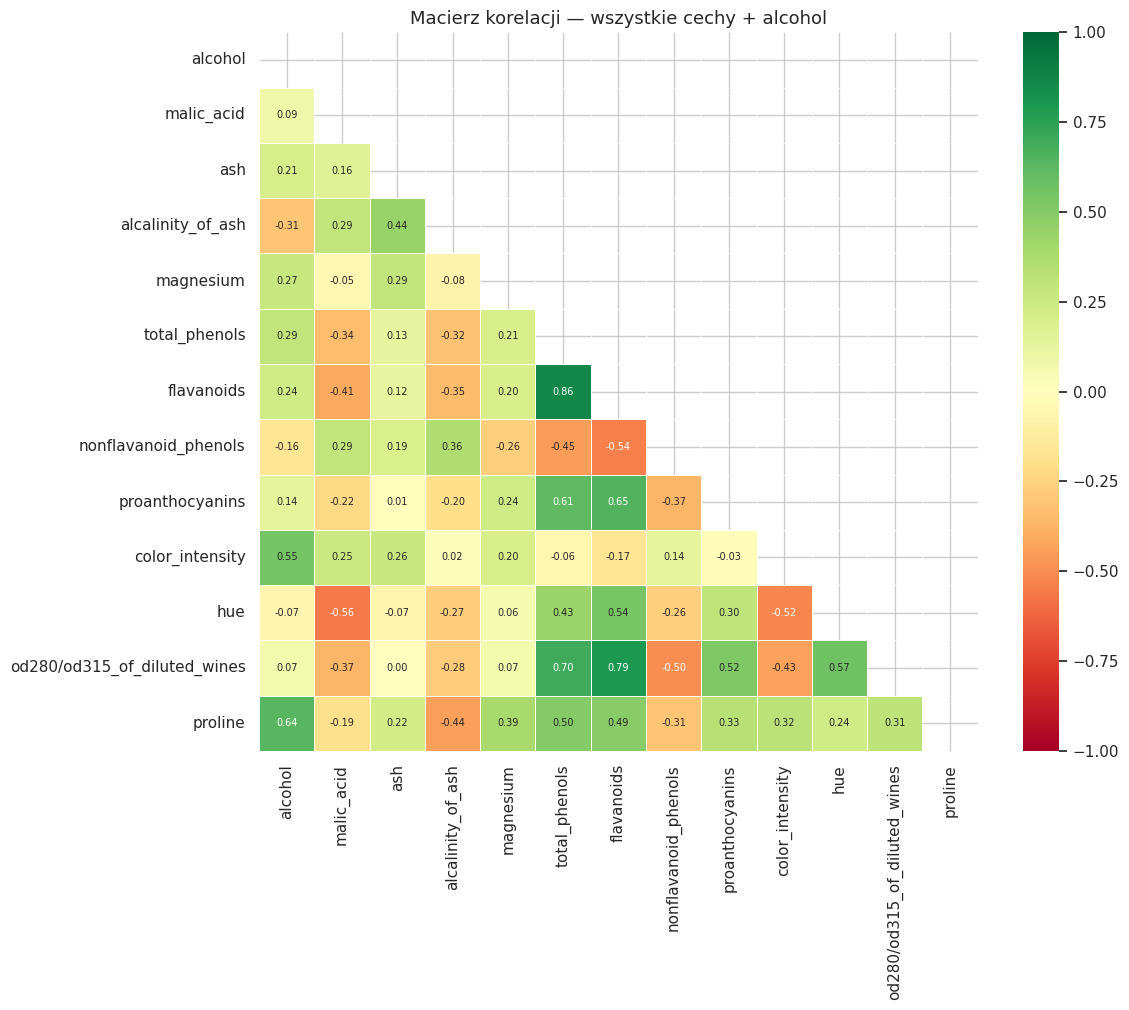


Pary cech o korelacji |r| > 0.7 (potencjalna multikolinearność):
  total_phenols                       ↔ flavanoids                           r=0.860
  flavanoids                          ↔ od280/od315_of_diluted_wines         r=0.790


In [9]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr().round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # ukrycie górnego trójkąta
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Macierz korelacji — wszystkie cechy + alcohol', fontsize=13)
plt.tight_layout()
plt.show()

# Wysoka korelacja między cechami wejściowymi = multikolinearność
# To może destabilizować wagi regresji liniowej — Ridge/Lasso temu zaradzą
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

print(f"\nPary cech o korelacji |r| > 0.7 (potencjalna multikolinearność):")
for a, b, v in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {a:35s} ↔ {b:35s}  r={v:.3f}")

#### EDA Insights:
1) There are no missing values or significant outliers.
2) Target variable has the biggest absolute correlation with `proline` (r=0.64) and `color intensity` (r=0.55). There are small negative correlations with `alcanity of ash` (r=-0.31), `nonflavanoin_phenols` (r=-0.16).
3) Multicollinearity: Two pairs of features pass the |r| > 0.7 treshold. Linear regression will potentially struggle with separating the individual impact of each of the features. Regulation methods might help with finding the actual relations between the features and the target. 

## 3. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Wydzielamy walidację z części treningowej (60/20/20)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=RANDOM_STATE
)

n_total = len(df)
print(f"Trening (do uczenia modeli): {len(X_train_sub)} próbek ({100*len(X_train_sub)/n_total:.1f}%)")
print(f"Walidacja (do doboru α):      {len(X_val)} próbek ({100*len(X_val)/n_total:.1f}%)")
print(f"Test (końcowa ocena):         {len(X_test)} próbek ({100*len(X_test)/n_total:.1f}%)")

print(f"\nRozkład y_train_sub: mean={y_train_sub.mean():.3f}, std={y_train_sub.std():.3f}")
print(f"Rozkład y_val:       mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"Rozkład y_test:      mean={y_test.mean():.3f}, std={y_test.std():.3f}")

Trening (do uczenia modeli): 106 próbek (59.6%)
Walidacja (do doboru α):      36 próbek (20.2%)
Test (końcowa ocena):         36 próbek (20.2%)

Rozkład y_train_sub: mean=12.969, std=0.788
Rozkład y_val:       mean=13.062, std=0.835
Rozkład y_test:      mean=13.033, std=0.842


## 4. Linear Regression + Metrics

In [11]:
# Baseline: klasyczna regresja liniowa (bez skalowania)
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

print(f"{'':6}  {'R²':>8}  {'MSE':>8}  {'RMSE':>8}")
print("-" * 36)
for label, y_true, y_pred in [
    ('Train', y_train, y_pred_train),
    ('Test', y_test, y_pred_test),
]:
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{label:6}  {r2:>8.4f}  {mse:>8.4f}  {rmse:>8.4f}")

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
gap = r2_train - r2_test

print(f"R² train: {r2_train:.4f}")
print(f"R² test:  {r2_test:.4f}")
print(f"Gap:      {gap:.4f}")

if gap > 0.05:
    print("⚠ możliwy overfitting")
elif gap < -0.05:
    print("⚠ model lepszy na teście niż na treningu — możliwy underfitting lub szczęśliwy traf")
else:
    print("✓ dobra generalizacja")

# Wersja ze standaryzacją cech: używamy jej do interpretacji wag
lr_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
lr_scaled.fit(X_train, y_train)

y_pred_train_scaled = lr_scaled.predict(X_train)
y_pred_test_scaled = lr_scaled.predict(X_test)
scaled_coefs = lr_scaled.named_steps['model'].coef_

print("\nPorównanie jakości OLS bez/ze skalowaniem (powinno być bardzo zbliżone):")
print(f"R² test bez skali: {r2_score(y_test, y_pred_test):.4f}")
print(f"R² test ze skalą:  {r2_score(y_test, y_pred_test_scaled):.4f}")
print(f"MSE test bez skali: {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MSE test ze skalą:  {mean_squared_error(y_test, y_pred_test_scaled):.4f}")

              R²       MSE      RMSE
------------------------------------
Train     0.5842    0.2668    0.5165
Test      0.5946    0.2872    0.5360
R² train: 0.5842
R² test:  0.5946
Gap:      -0.0104
✓ dobra generalizacja

Porównanie jakości OLS bez/ze skalowaniem (powinno być bardzo zbliżone):
R² test bez skali: 0.5946
R² test ze skalą:  0.5946
MSE test bez skali: 0.2872
MSE test ze skalą:  0.2872


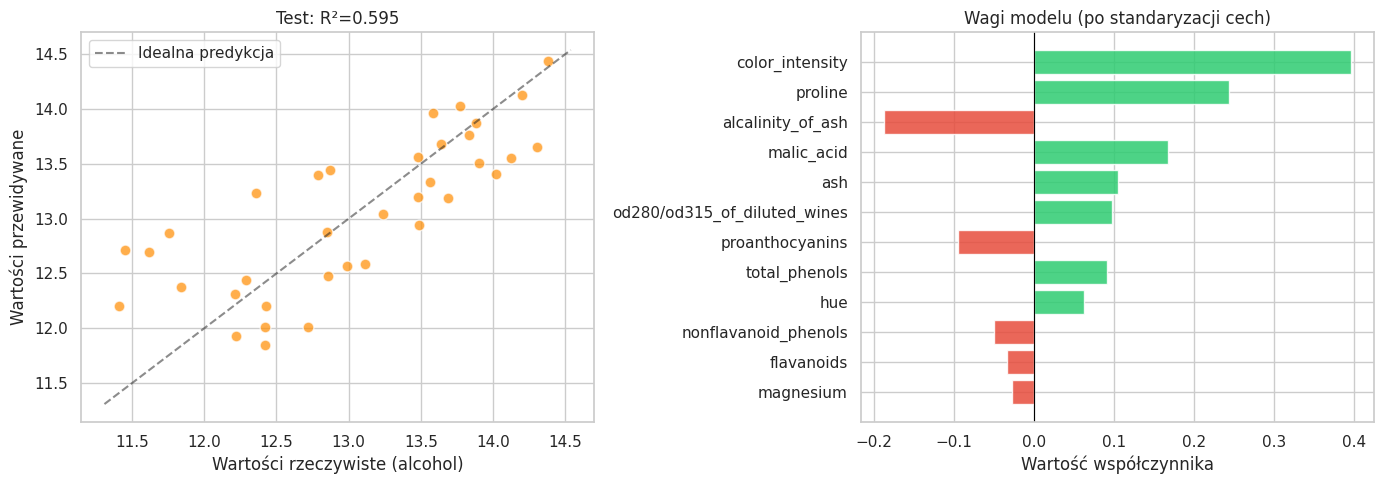


Największa waga bezwzględna: 0.396  (color_intensity)
Intercept (model standaryzowany): 12.9925


In [12]:
pythonfig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewy wykres: rzeczywiste vs przewidywane (zbiór testowy)
axes[0].scatter(y_test, y_pred_test_scaled, alpha=0.7, color='darkorange', edgecolors='white', s=60)
lims = [min(y_test.min(), y_pred_test_scaled.min()) - 0.1,
        max(y_test.max(), y_pred_test_scaled.max()) + 0.1]
axes[0].plot(lims, lims, 'k--', alpha=0.5, label='Idealna predykcja')
axes[0].set_xlabel('Wartości rzeczywiste (alcohol)')
axes[0].set_ylabel('Wartości przewidywane')
axes[0].set_title(f'Test: R²={r2_score(y_test, y_pred_test_scaled):.3f}')
axes[0].legend()

# Prawy wykres: wagi modelu po standaryzacji cech (porównywalna skala)
coef_df = pd.DataFrame({
    'cecha': feature_cols,
    'waga': scaled_coefs
}).sort_values('waga', key=abs, ascending=True)  # ascending=True bo barh

colors = ['#e74c3c' if w < 0 else '#2ecc71' for w in coef_df['waga']]
axes[1].barh(coef_df['cecha'], coef_df['waga'], color=colors, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Wagi modelu (po standaryzacji cech)')
axes[1].set_xlabel('Wartość współczynnika')

plt.tight_layout()
plt.show()

# Duże wagi + multikolinearność z EDA = potencjalnie niestabilne przypisanie wpływu
print(f"\nNajwiększa waga bezwzględna: {coef_df['waga'].abs().max():.3f}  ({coef_df.iloc[-1]['cecha']})")
print(f"Intercept (model standaryzowany): {lr_scaled.named_steps['model'].intercept_:.4f}")

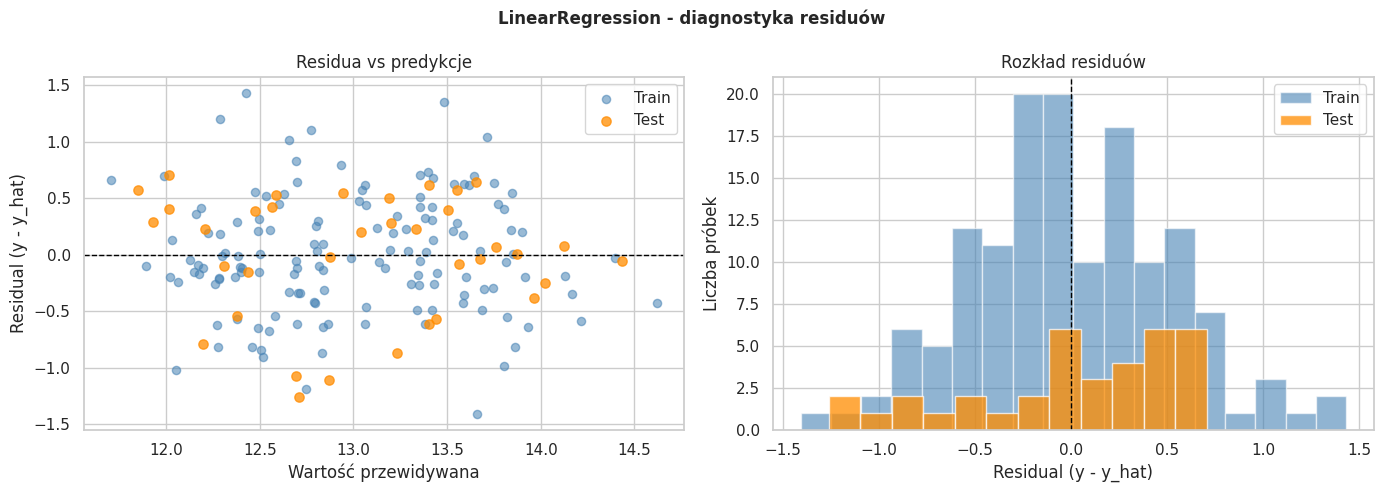

In [13]:
# Diagnostyka założeń: residua vs predykcje oraz rozkład residuów
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_train, residuals_train, alpha=0.55, s=35, label='Train', color='steelblue')
axes[0].scatter(y_pred_test, residuals_test, alpha=0.75, s=45, label='Test', color='darkorange')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Wartość przewidywana')
axes[0].set_ylabel('Residual (y - y_hat)')
axes[0].set_title('Residua vs predykcje')
axes[0].legend()

axes[1].hist(residuals_train, bins=18, alpha=0.6, label='Train', color='steelblue', edgecolor='white')
axes[1].hist(residuals_test, bins=12, alpha=0.75, label='Test', color='darkorange', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (y - y_hat)')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_title('Rozkład residuów')
axes[1].legend()

plt.suptitle('LinearRegression - diagnostyka residuów', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

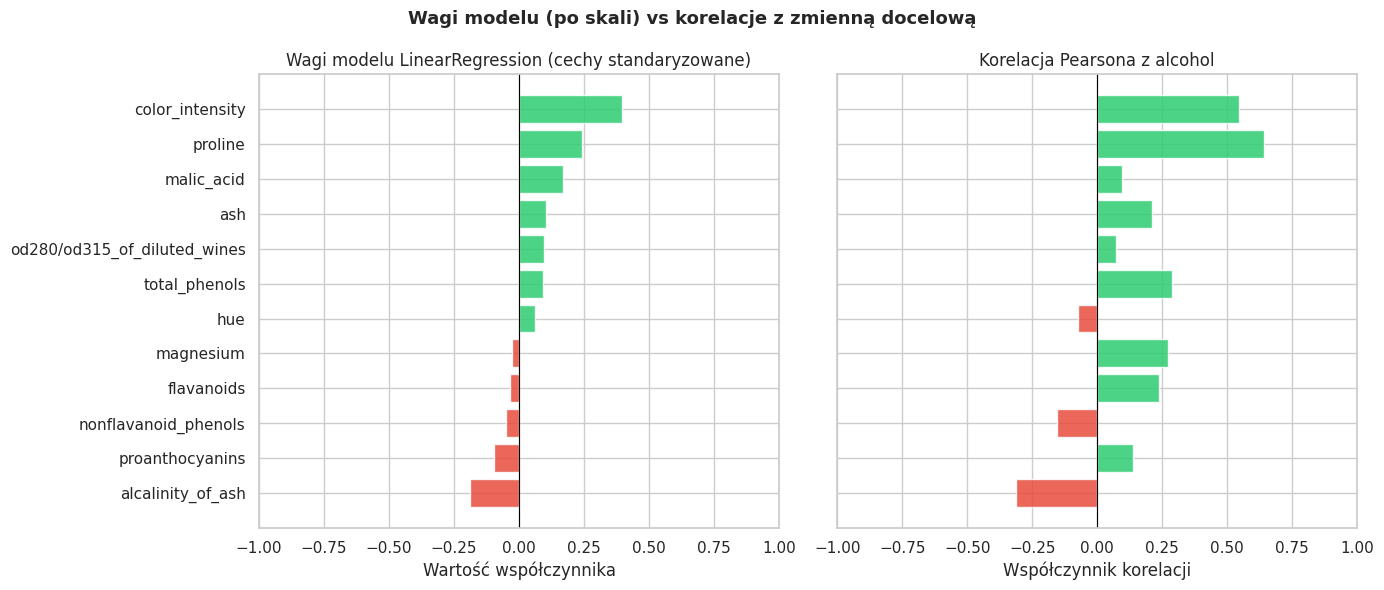

In [14]:
coef_df = pd.DataFrame({
    'cecha': feature_cols,
    'waga': scaled_coefs,
    'korelacja': [correlations[f] for f in feature_cols]
}).sort_values('waga', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

colors_coef = ['#e74c3c' if w < 0 else '#2ecc71' for w in coef_df['waga']]
axes[0].barh(coef_df['cecha'], coef_df['waga'], color=colors_coef, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlim(-1, 1)
axes[0].set_title('Wagi modelu LinearRegression (cechy standaryzowane)')
axes[0].set_xlabel('Wartość współczynnika')

colors_corr = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['korelacja']]
axes[1].barh(coef_df['cecha'], coef_df['korelacja'], color=colors_corr, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlim(-1, 1)
axes[1].set_title('Korelacja Pearsona z alcohol')
axes[1].set_xlabel('Współczynnik korelacji')

plt.suptitle('Wagi modelu (po skali) vs korelacje z zmienną docelową', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Linear Regression + Metrics insights
1) Model osiągnął bardzo podobne wartości `R²` na treningu i teście (około 0.59), czyli wyjaśnia ok. 59% wariancji zmiennej docelowej. `RMSE` około 0.53 oznacza przeciętny błąd rzędu ~0.53 p.p. alkoholu przy zakresie targetu mniej więcej [11.0, 14.8]. Mały gap między train i test wskazuje dobrą generalizację.

2) Wagi modelu interpretujemy na cechach standaryzowanych, dzięki czemu ich skala jest porównywalna. Mimo to nadal widać różnice między korelacją Pearsona a wagami modelu wielowymiarowego. Przykłady:
- `proline` ma najwyższą korelację z `alcohol`, ale po uwzględnieniu pozostałych cech, jego waga wynosi tylko trochę poniżej 0.25.
- Największe bezwzględne wagi mają `color_intensity`, `proline` i `alcalinity_of_ash`, wszystkie miały też najwyższą wartość bezwględną korelacji Pearsona.
- Dla cech (`proanthocyanins`, `flavanoids`, `magnesium` i `hue` znak współczynnika zmienia się względem korelacji, co jest typowym efektem współliniowości.

## 5. Ridge and Lasso regularization

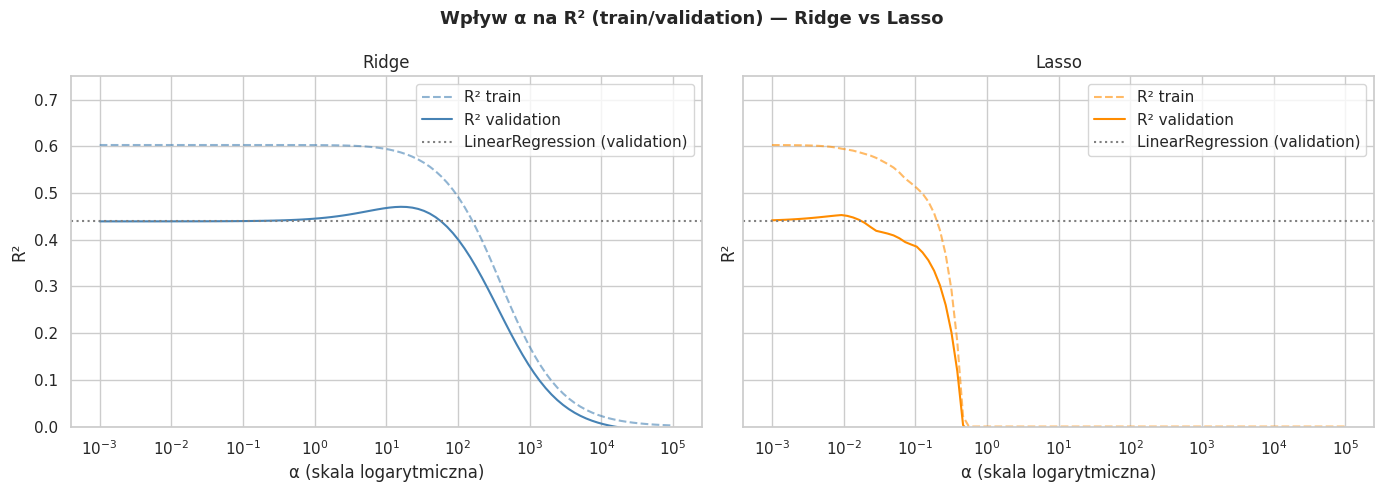

In [15]:
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-3, 5, 100)  # 100 wartości α od 1e-3 do 1e5

results = {
    'ridge': {'r2_train': [], 'r2_val': [], 'mse_val': [], 'coefs': []},
    'lasso': {'r2_train': [], 'r2_val': [], 'mse_val': [], 'coefs': []},
}

for alpha in alphas:
    for name, estimator in [
        ('ridge', Ridge(alpha=alpha)),
        ('lasso', Lasso(alpha=alpha, max_iter=10000, random_state=RANDOM_STATE)),
    ]:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('model', estimator),
        ])
        model.fit(X_train_sub, y_train_sub)

        y_pred_train_sub = model.predict(X_train_sub)
        y_pred_val = model.predict(X_val)

        results[name]['r2_train'].append(r2_score(y_train_sub, y_pred_train_sub))
        results[name]['r2_val'].append(r2_score(y_val, y_pred_val))
        results[name]['mse_val'].append(mean_squared_error(y_val, y_pred_val))
        results[name]['coefs'].append(model.named_steps['model'].coef_.copy())

baseline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
baseline_lr.fit(X_train_sub, y_train_sub)
baseline_r2_val = r2_score(y_val, baseline_lr.predict(X_val))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, name, color in zip(axes, ['ridge', 'lasso'], ['steelblue', 'darkorange']):
    ax.semilogx(alphas, results[name]['r2_train'], '--', color=color, alpha=0.6, label='R² train')
    ax.semilogx(alphas, results[name]['r2_val'], '-', color=color, label='R² validation')
    ax.axhline(baseline_r2_val, color='gray', linestyle=':', label='LinearRegression (validation)')
    ax.set_xlabel('α (skala logarytmiczna)')
    ax.set_ylabel('R²')
    ax.set_ylim(0, 0.75)
    ax.set_title(name.capitalize())
    ax.legend()

plt.suptitle('Wpływ α na R² (train/validation) — Ridge vs Lasso', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Insights:
1) Dla `Ridge` małe wartości (poniżej 0), mają niewielki wpływ na metryki, peak R2 zachodzi między 10^1 i 10^2, po osiągnięciu peaku, R2 spada do 0.
2) `Lasso` zachowuje się inaczej: po przekroczeniu pewnego α zaczyna agresywnie zerować współczynniki, co może prowadzić do spadku R2 przy zbyt silnej regularizacji. Peak R2 jest gdzieś w okolicy 10^-2.
3) Szczytowe wartości `R²` dla Ridge i Lasso są podobne, ale Lasso jest bardziej wrażliwe na wybór α.

### (5b) Ridge/Lasso: porównanie z i bez standaryzacji
Poniżej porównujemy zachowanie modeli na **tym samym** podziale train/validation/test i tej samej siatce `α`.
`R² validation` służy do wyboru `α`, a `R² test` tylko do końcowej oceny.
Nie używamy `R²` na całym zbiorze do strojenia, żeby uniknąć data leakage.

Model              best α   R² train     R² val    R² test   MSE test
--------------------------------------------------------------------------
Ridge scaled      15.9228     0.5870     0.4706     0.6001     0.2833
Ridge raw         10.9750     0.5860     0.4614     0.6447     0.2517
Lasso scaled       0.0093     0.5951     0.4529     0.6258     0.2652
Lasso raw          0.0053     0.5904     0.4547     0.6349     0.2587

Uwaga: α dobieramy po walidacji; test jest używany wyłącznie do finalnej oceny.


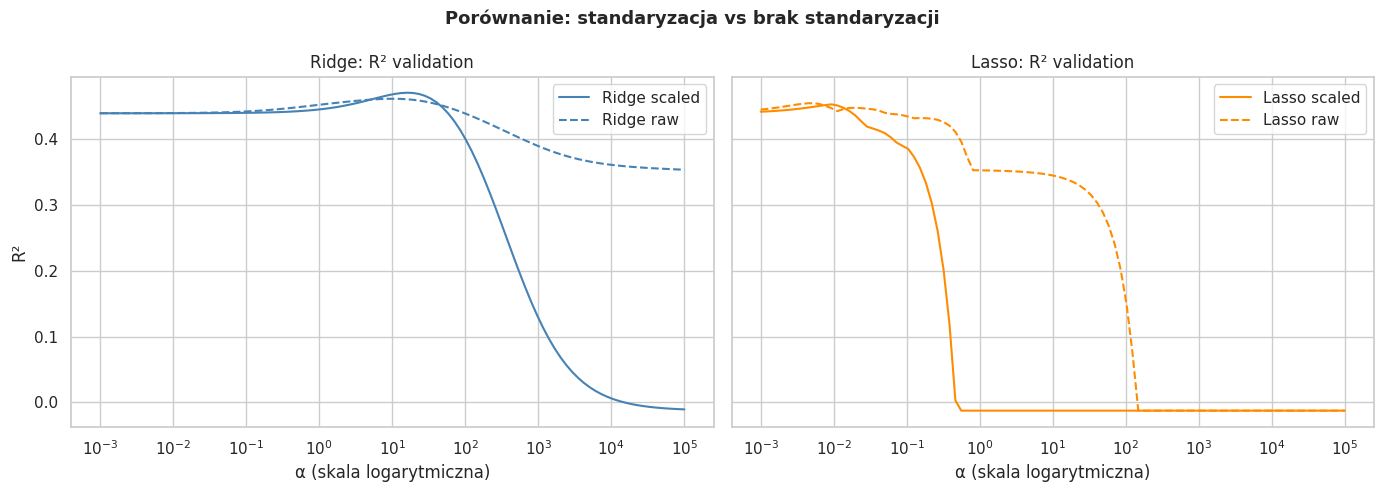

In [16]:
comparison = {
    'ridge': {'r2_train_scaled': [], 'r2_train_raw': [], 'r2_val_scaled': [], 'r2_val_raw': []},
    'lasso': {'r2_train_scaled': [], 'r2_train_raw': [], 'r2_val_scaled': [], 'r2_val_raw': []},
}

for alpha in alphas:
    ridge_scaled = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha)),
    ])
    ridge_raw = Ridge(alpha=alpha)

    lasso_scaled = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=alpha, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    lasso_raw = Lasso(alpha=alpha, max_iter=10000, random_state=RANDOM_STATE)

    ridge_scaled.fit(X_train_sub, y_train_sub)
    ridge_raw.fit(X_train_sub, y_train_sub)
    lasso_scaled.fit(X_train_sub, y_train_sub)
    lasso_raw.fit(X_train_sub, y_train_sub)

    comparison['ridge']['r2_train_scaled'].append(r2_score(y_train_sub, ridge_scaled.predict(X_train_sub)))
    comparison['ridge']['r2_train_raw'].append(r2_score(y_train_sub, ridge_raw.predict(X_train_sub)))
    comparison['ridge']['r2_val_scaled'].append(r2_score(y_val, ridge_scaled.predict(X_val)))
    comparison['ridge']['r2_val_raw'].append(r2_score(y_val, ridge_raw.predict(X_val)))

    comparison['lasso']['r2_train_scaled'].append(r2_score(y_train_sub, lasso_scaled.predict(X_train_sub)))
    comparison['lasso']['r2_train_raw'].append(r2_score(y_train_sub, lasso_raw.predict(X_train_sub)))
    comparison['lasso']['r2_val_scaled'].append(r2_score(y_val, lasso_scaled.predict(X_val)))
    comparison['lasso']['r2_val_raw'].append(r2_score(y_val, lasso_raw.predict(X_val)))

# Najlepsze alpha wybieramy po R² na walidacji
idx_ridge_scaled = int(np.argmax(comparison['ridge']['r2_val_scaled']))
idx_ridge_raw = int(np.argmax(comparison['ridge']['r2_val_raw']))
idx_lasso_scaled = int(np.argmax(comparison['lasso']['r2_val_scaled']))
idx_lasso_raw = int(np.argmax(comparison['lasso']['r2_val_raw']))

best_models = {
    'Ridge scaled': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=alphas[idx_ridge_scaled]))]),
    'Ridge raw': Ridge(alpha=alphas[idx_ridge_raw]),
    'Lasso scaled': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=alphas[idx_lasso_scaled], max_iter=10000, random_state=RANDOM_STATE))]),
    'Lasso raw': Lasso(alpha=alphas[idx_lasso_raw], max_iter=10000, random_state=RANDOM_STATE),
}

print(f"{'Model':14} {'best α':>10} {'R² train':>10} {'R² val':>10} {'R² test':>10} {'MSE test':>10}")
print('-' * 74)
for name, model in best_models.items():
    model.fit(X_train_sub, y_train_sub)
    pred_train = model.predict(X_train_sub)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)
    alpha_used = model.named_steps['model'].alpha if isinstance(model, Pipeline) else model.alpha
    print(
        f"{name:14} {alpha_used:>10.4f} {r2_score(y_train_sub, pred_train):>10.4f} "
        f"{r2_score(y_val, pred_val):>10.4f} {r2_score(y_test, pred_test):>10.4f} "
        f"{mean_squared_error(y_test, pred_test):>10.4f}"
    )

print("\nUwaga: α dobieramy po walidacji; test jest używany wyłącznie do finalnej oceny.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].semilogx(alphas, comparison['ridge']['r2_val_scaled'], label='Ridge scaled', color='steelblue')
axes[0].semilogx(alphas, comparison['ridge']['r2_val_raw'], '--', label='Ridge raw', color='steelblue')
axes[0].set_title('Ridge: R² validation')
axes[0].set_xlabel('α (skala logarytmiczna)')
axes[0].set_ylabel('R²')
axes[0].legend()

axes[1].semilogx(alphas, comparison['lasso']['r2_val_scaled'], label='Lasso scaled', color='darkorange')
axes[1].semilogx(alphas, comparison['lasso']['r2_val_raw'], '--', label='Lasso raw', color='darkorange')
axes[1].set_title('Lasso: R² validation')
axes[1].set_xlabel('α (skala logarytmiczna)')
axes[1].legend()

plt.suptitle('Porównanie: standaryzacja vs brak standaryzacji', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

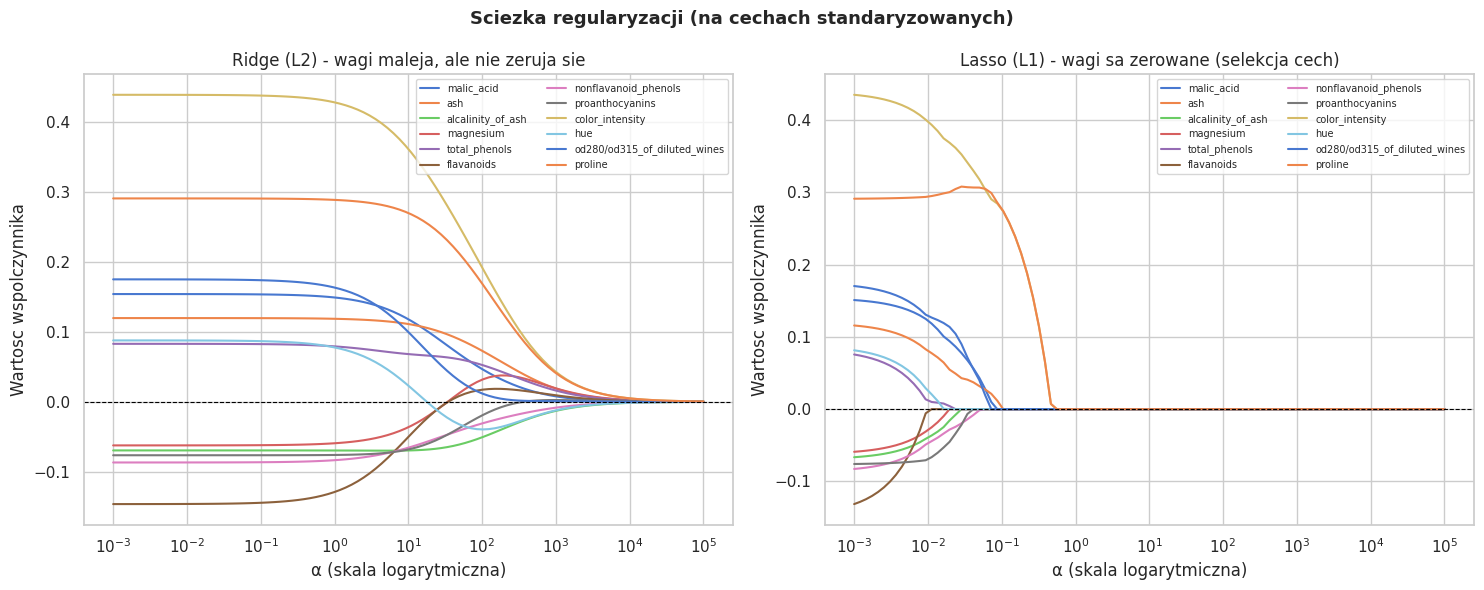

Liczba cech z waga = 0 w Lasso:
  pierwszy α z zerowaniem: 0.0112 -> 1/12 cech
  α=100000.0: 12/12 cech wyzerowanych


In [17]:
coefs_ridge = np.array(results['ridge']['coefs'])  # shape: (100, n_features)
coefs_lasso = np.array(results['lasso']['coefs'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, coefs, title in zip(
    axes,
    [coefs_ridge, coefs_lasso],
    ['Ridge (L2) - wagi maleja, ale nie zeruja sie',
     'Lasso (L1) - wagi sa zerowane (selekcja cech)']
 ):
    for i, feat in enumerate(feature_cols):
        ax.semilogx(alphas, coefs[:, i], label=feat, linewidth=1.5)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('α (skala logarytmiczna)')
    ax.set_ylabel('Wartosc wspolczynnika')
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.suptitle('Sciezka regularyzacji (na cechach standaryzowanych)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Ile cech Lasso wyzerowalo przy roznych α?
print('Liczba cech z waga = 0 w Lasso:')
first_zero_alpha = None
for i, alpha in enumerate(alphas):
    n_zero = (np.abs(coefs_lasso[i]) < 1e-6).sum()
    if n_zero > 0 and first_zero_alpha is None:
        first_zero_alpha = alpha
        print(f'  pierwszy α z zerowaniem: {alpha:.4f} -> {n_zero}/{len(feature_cols)} cech')

print(f'  α={alphas[-1]:.1f}: {(np.abs(coefs_lasso[-1]) < 1e-6).sum()}/{len(feature_cols)} cech wyzerowanych')

### (5c) Ścieżka regularyzacji na cechach niestandaryzowanych
Ten wykres pokazuje, jak zmieniają się współczynniki przy rosnącym `α` bez wcześniejszego skalowania cech.

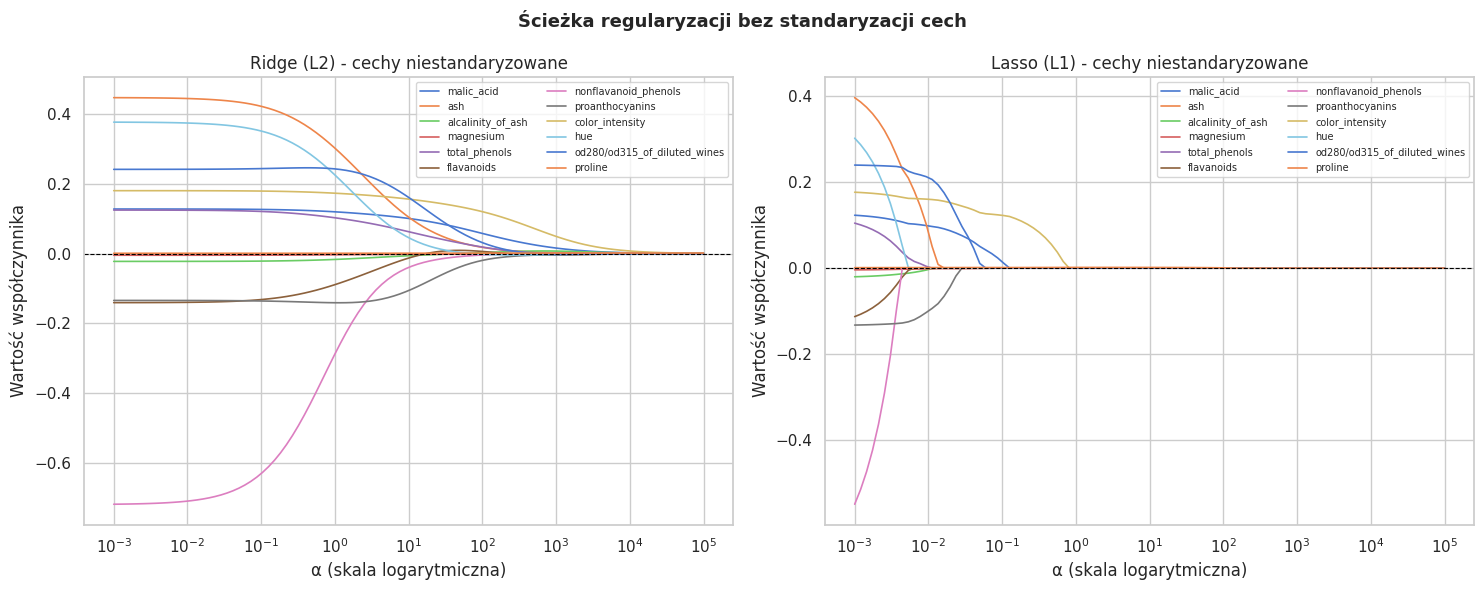

In [18]:
coefs_ridge_raw = []
coefs_lasso_raw = []

for alpha in alphas:
    ridge_raw = Ridge(alpha=alpha)
    lasso_raw = Lasso(alpha=alpha, max_iter=10000, random_state=RANDOM_STATE)

    ridge_raw.fit(X_train_sub, y_train_sub)
    lasso_raw.fit(X_train_sub, y_train_sub)

    coefs_ridge_raw.append(ridge_raw.coef_.copy())
    coefs_lasso_raw.append(lasso_raw.coef_.copy())

coefs_ridge_raw = np.array(coefs_ridge_raw)
coefs_lasso_raw = np.array(coefs_lasso_raw)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, coefs, title in zip(
    axes,
    [coefs_ridge_raw, coefs_lasso_raw],
    ['Ridge (L2) - cechy niestandaryzowane',
     'Lasso (L1) - cechy niestandaryzowane']
 ):
    for i, feat in enumerate(feature_cols):
        ax.semilogx(alphas, coefs[:, i], label=feat, linewidth=1.2)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('α (skala logarytmiczna)')
    ax.set_ylabel('Wartość współczynnika')
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.suptitle('Ścieżka regularyzacji bez standaryzacji cech', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Insights
1) Widać wyraźną różnicę w przebiegu ścieżek współczynników dla `Ridge` i `Lasso`.
2) W `Ridge` wagi maleją płynnie i zbliżają się do zera, ale zwykle go nie osiągają.
3) W `Lasso` współczynniki są zerowane skokowo, co realizuje selekcję cech.
4) Cechy silnie skorelowane często są redukowane podobnie (jedna z nich może zostać "wypchnięta" do zera).

In [19]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV i LassoCV robią k-fold CV wewnętrznie dla każdego α
ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas, cv=5)),
])
lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=RANDOM_STATE)),
])

ridge_cv.fit(X_train, y_train)
lasso_cv.fit(X_train, y_train)

ridge_cv_alpha = ridge_cv.named_steps['model'].alpha_
lasso_cv_alpha = lasso_cv.named_steps['model'].alpha_

print(f"Optymalny α (Ridge CV): {ridge_cv_alpha:.4f}")
print(f"Optymalny α (Lasso CV): {lasso_cv_alpha:.4f}")

# "Ręczny" dobór α wykonujemy na walidacji, nie na teście
best_ridge_manual_idx = int(np.argmax(results['ridge']['r2_val']))
best_lasso_manual_idx = int(np.argmax(results['lasso']['r2_val']))
best_ridge_manual_alpha = alphas[best_ridge_manual_idx]
best_lasso_manual_alpha = alphas[best_lasso_manual_idx]

print(f"\n{'':32} {'Ridge':>10}  {'Lasso':>10}")
print("-" * 56)
print(f"{'α ręczny (best R² validation)':32} {best_ridge_manual_alpha:>10.4f}  {best_lasso_manual_alpha:>10.4f}")
print(f"{'α z CV':32} {ridge_cv_alpha:>10.4f}  {lasso_cv_alpha:>10.4f}")

Optymalny α (Ridge CV): 27.8256
Optymalny α (Lasso CV): 0.0236

                                      Ridge       Lasso
--------------------------------------------------------
α ręczny (best R² validation)       15.9228      0.0093
α z CV                              27.8256      0.0236


In [20]:
models = {
    'LinearRegression (bez reg.)': LinearRegression(),
    f'Ridge (α manual={best_ridge_manual_alpha:.3f})': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=best_ridge_manual_alpha)),
    ]),
    f'Ridge (α CV={ridge_cv_alpha:.3f})': ridge_cv,
    f'Lasso (α manual={best_lasso_manual_alpha:.3f})': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=best_lasso_manual_alpha, max_iter=10000, random_state=RANDOM_STATE)),
    ]),
    f'Lasso (α CV={lasso_cv_alpha:.3f})': lasso_cv,
}

print(f"{'Model':38}  {'R² train':>8}  {'R² test':>8}  {'MSE test':>9}")
print("-" * 72)
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    r2_tr = r2_score(y_train, pred_train)
    r2_te = r2_score(y_test, pred_test)
    mse = mean_squared_error(y_test, pred_test)
    print(f"{name:38}  {r2_tr:>8.4f}  {r2_te:>8.4f}  {mse:>9.4f}")

Model                                   R² train   R² test   MSE test
------------------------------------------------------------------------
LinearRegression (bez reg.)               0.5842    0.5946     0.2872
Ridge (α manual=15.923)                   0.5775    0.6067     0.2786
Ridge (α CV=27.826)                       0.5691    0.6051     0.2798
Lasso (α manual=0.009)                    0.5810    0.6164     0.2718
Lasso (α CV=0.024)                        0.5699    0.6315     0.2611


### (5d) Porownanie wag cech przed i po regularyzacji (alpha wybrane przez CV)
Dwa wykresy ponizej porownuja wspolczynniki OLS (bez regularyzacji) z Ridge i Lasso dla alpha wybranych przez 5-fold CV.

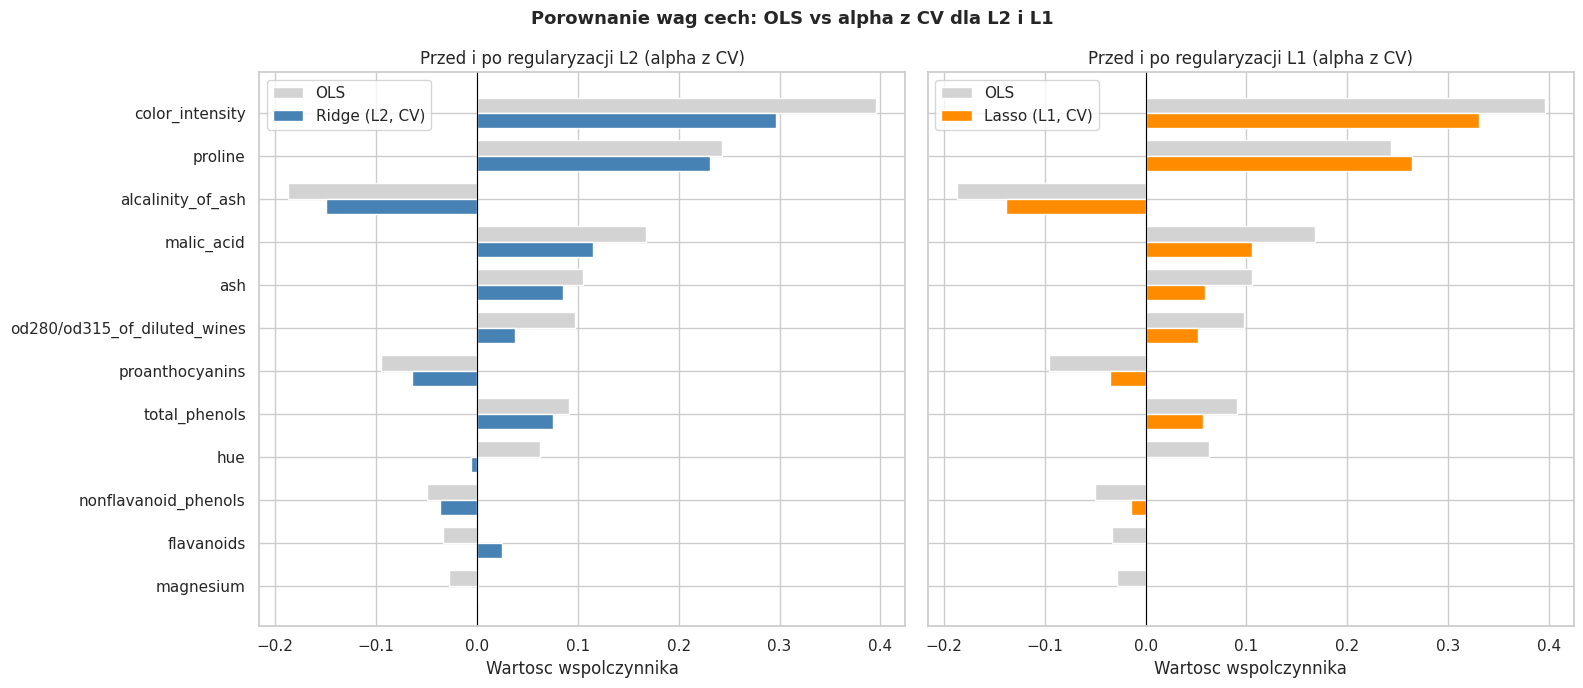

,cecha,OLS (bez regularyzacji),Ridge L2 (alpha CV=27.8256),Lasso L1 (alpha CV=0.0236)
0,magnesium,-0.0280,0.0010,-0.0000
1,flavanoids,-0.0333,0.0245,0.0000
2,nonflavanoid_phenols,-0.0497,-0.0367,-0.0150
3,hue,0.0626,-0.0061,0.0000
4,total_phenols,0.0909,0.0749,0.0570
5,proanthocyanins,-0.0953,-0.0642,-0.0352
6,od280/od315_of_diluted_wines,0.0975,0.0373,0.0521
7,ash,0.1051,0.0852,0.0586
8,malic_acid,0.1678,0.1148,0.1055
9,alcalinity_of_ash,-0.1869,-0.1500,-0.1385


Lasso wyzerowal 3/12 cech dla alpha CV=0.0236.


In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Porownujemy wspolczynniki na tej samej skali (po standaryzacji cech)
try:
    ridge_alpha_best = float(ridge_cv_alpha)
    lasso_alpha_best = float(lasso_cv_alpha)
except NameError as exc:
    raise NameError(
        'Brak ridge_cv_alpha/lasso_cv_alpha. Uruchom najpierw komorke z RidgeCV i LassoCV.'
    ) from exc

ols_ref = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
ridge_ref = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=ridge_alpha_best)),
])
lasso_ref = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=lasso_alpha_best, max_iter=10000, random_state=RANDOM_STATE)),
])

ols_ref.fit(X_train, y_train)
ridge_ref.fit(X_train, y_train)
lasso_ref.fit(X_train, y_train)

ridge_col = f'Ridge L2 (alpha CV={ridge_alpha_best:.4f})'
lasso_col = f'Lasso L1 (alpha CV={lasso_alpha_best:.4f})'

coef_compare = pd.DataFrame({
    'cecha': feature_cols,
    'OLS (bez regularyzacji)': ols_ref.named_steps['model'].coef_,
    ridge_col: ridge_ref.named_steps['model'].coef_,
    lasso_col: lasso_ref.named_steps['model'].coef_,
})

order = coef_compare['OLS (bez regularyzacji)'].abs().sort_values(ascending=True).index
coef_compare = coef_compare.iloc[order].reset_index(drop=True)

y_pos = np.arange(len(coef_compare))
bar_h = 0.36

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

axes[0].barh(
    y_pos + bar_h / 2,
    coef_compare['OLS (bez regularyzacji)'],
    height=bar_h,
    color='lightgray',
    edgecolor='white',
    label='OLS'
)
axes[0].barh(
    y_pos - bar_h / 2,
    coef_compare[ridge_col],
    height=bar_h,
    color='steelblue',
    edgecolor='white',
    label='Ridge (L2, CV)'
)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(coef_compare['cecha'])
axes[0].set_title('Przed i po regularyzacji L2 (alpha z CV)')
axes[0].set_xlabel('Wartosc wspolczynnika')
axes[0].legend()

axes[1].barh(
    y_pos + bar_h / 2,
    coef_compare['OLS (bez regularyzacji)'],
    height=bar_h,
    color='lightgray',
    edgecolor='white',
    label='OLS'
)
axes[1].barh(
    y_pos - bar_h / 2,
    coef_compare[lasso_col],
    height=bar_h,
    color='darkorange',
    edgecolor='white',
    label='Lasso (L1, CV)'
)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Przed i po regularyzacji L1 (alpha z CV)')
axes[1].set_xlabel('Wartosc wspolczynnika')
axes[1].legend()

plt.suptitle('Porownanie wag cech: OLS vs alpha z CV dla L2 i L1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(coef_compare.round(4))

n_zero_lasso = int((np.abs(coef_compare[lasso_col]) < 1e-6).sum())
print(f'Lasso wyzerowal {n_zero_lasso}/{len(feature_cols)} cech dla alpha CV={lasso_alpha_best:.4f}.')

#### Insights:
1) Wszystkie warianty regularyzacji poprawiają wynik `R² test` względem bazowego modelu bez regularyzacji.
2) Dobór "manualnego" α na zbiorze walidacyjnym daje zwykle wynik zbliżony do α wyznaczonego przez 5-fold CV.
3) Ewaluacja na pojedynczym podziale train/test bywa niestabilna, dlatego wybór hiperparametrów przez CV lub walidację jest bezpieczniejszy metodologicznie.
4) Porównanie z i bez standaryzacji warto raportować: brak skali może dać lepszy wynik na pojedynczym splicie, ale standaryzacja daje bardziej porównywalne współczynniki i stabilniejszą interpretację modelu.